In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("machine_failure.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (10000, 14)


In [6]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [7]:
print("Data types:")
print(df.dtypes)

Data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
print("Machine failure distribution:")
print(df["Machine failure"].value_counts())

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [11]:
print("Machine failure percentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine failure percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

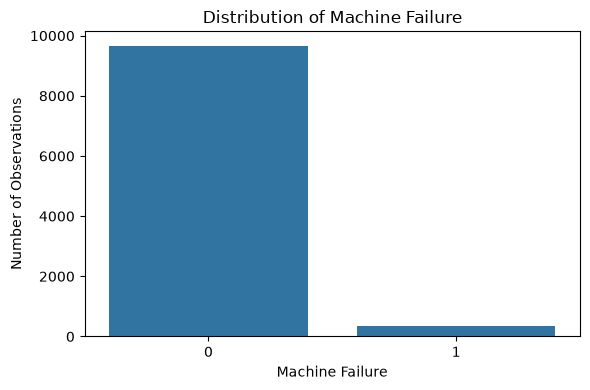

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Machine failure", data=df)

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

### Observation

- The dataset is highly imbalanced.
- Most observations belong to class 0 (no machine failure), while a small number belong to class 1 (machine failure).
- Class 0 contains more than 8500 observations, while class 1 contains less than 500 observations.

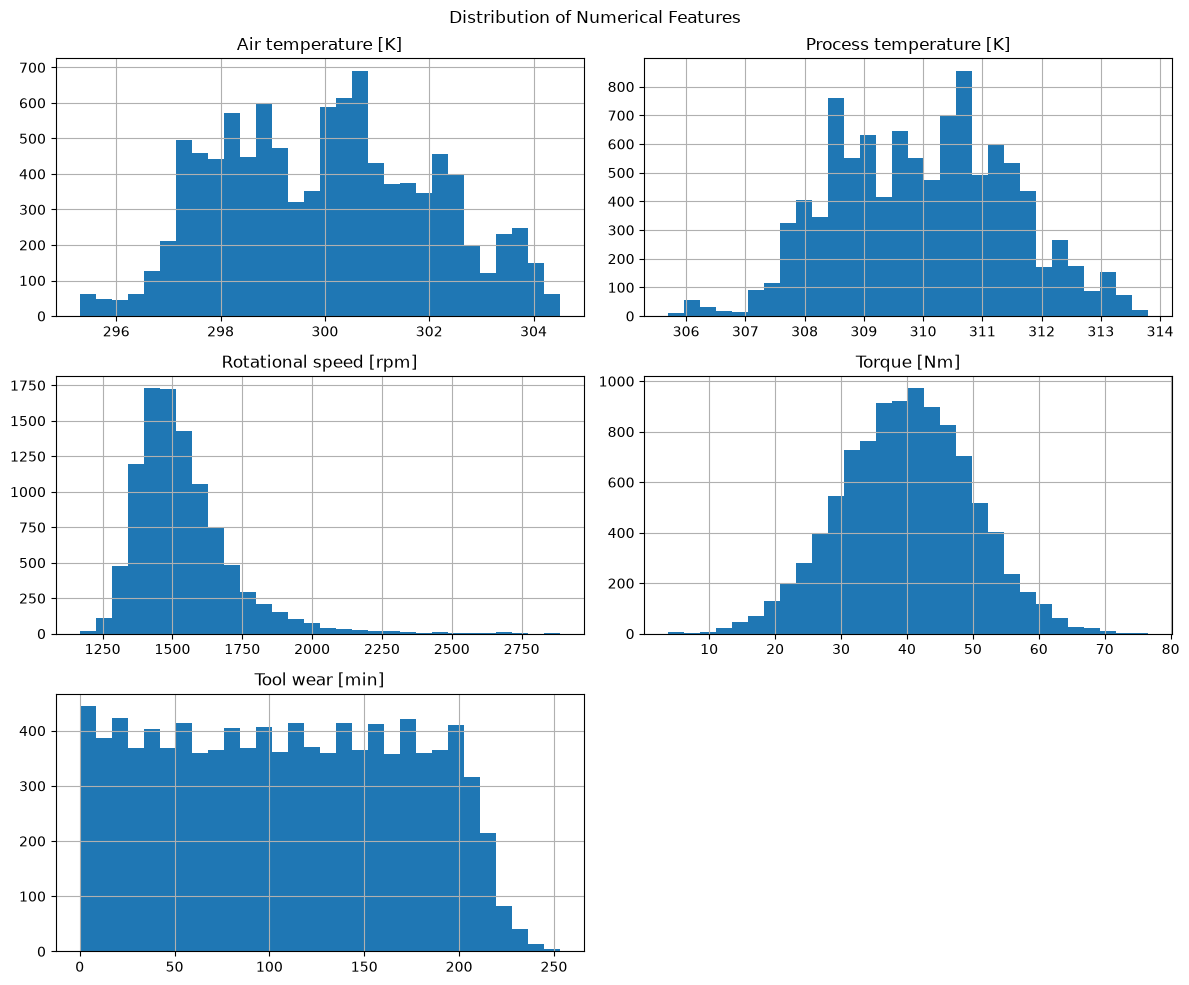

In [15]:
numerical_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numerical_columns].hist(
    figsize=(12, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

### Observation

- Air temperature and Process temperature are distributed within a relatively narrow range.
- Rotational speed is mostly concentrated around 1300–1700 rpm, with some higher values.
- Torque is mainly concentrated around 30–50 Nm.
- Tool wear is spread across a wide range, with fewer observations at higher values.

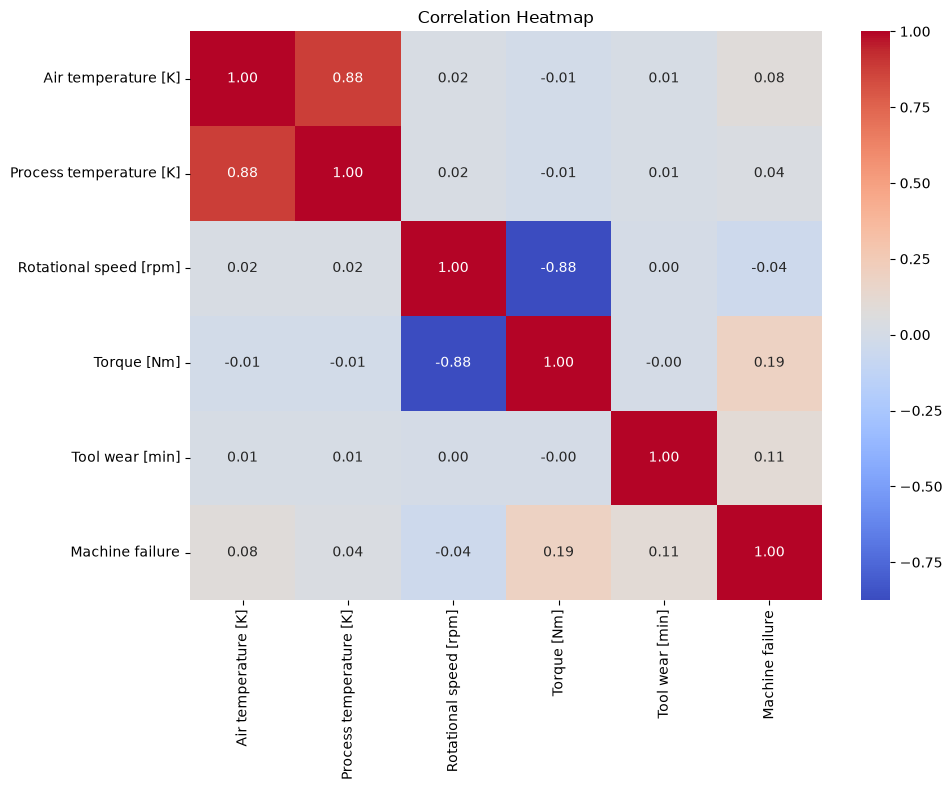

In [16]:
plt.figure(figsize=(10, 8))

correlation = df[numerical_columns + ["Machine failure"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

- The heatmap shows the correlation between the numerical features.
- Air temperature and Process temperature have a strong positive correlation.
- Rotational speed and Torque show a negative correlation.
- The remaining features show relatively weaker correlations with each other.

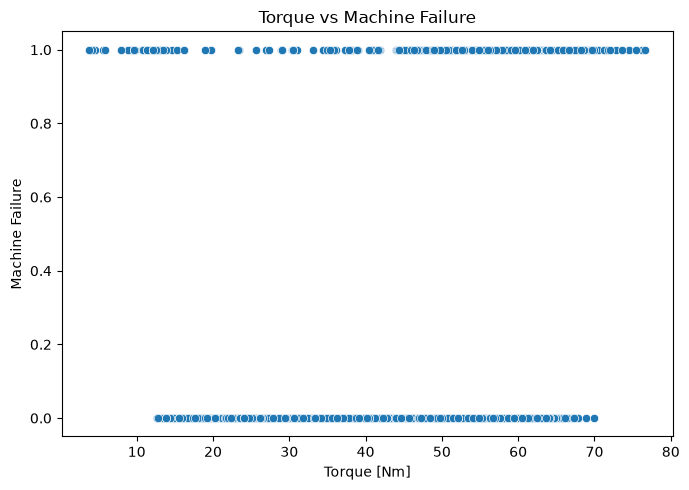

In [17]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Torque [Nm]",
    y="Machine failure"
)

plt.title("Torque vs Machine Failure")
plt.xlabel("Torque [Nm]")
plt.ylabel("Machine Failure")

plt.tight_layout()
plt.show()

### Observation

- Both failure and non-failure cases are present across a wide range of torque values.
- There is no clear separation between the two classes based only on torque.

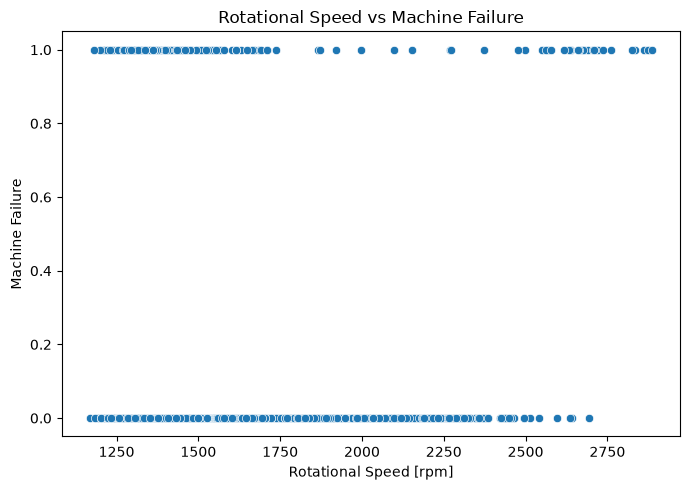

In [18]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Machine failure"
)

plt.title("Rotational Speed vs Machine Failure")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Machine Failure")

plt.tight_layout()
plt.show()

### Observation

- Both failure and non-failure cases occur across a wide range of rotational speeds.
- There is no clear separation between the two classes based only on rotational speed.

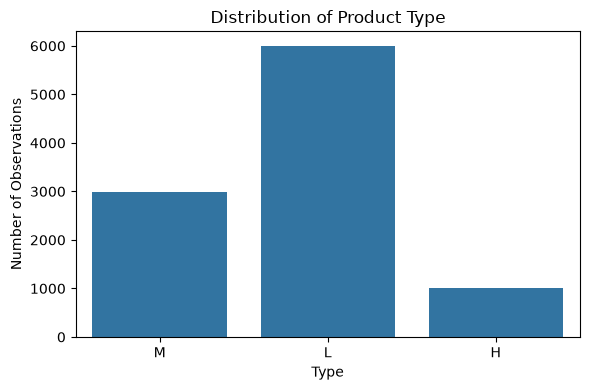

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Type", data=df)

plt.title("Distribution of Product Type")
plt.xlabel("Type")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()


### Observation

- The dataset contains three product quality types: L (Low), M (Medium), and H (High).
- Type L has the highest number of observations, followed by M, then H, indicating the product mix is skewed toward lower-quality-tier items.

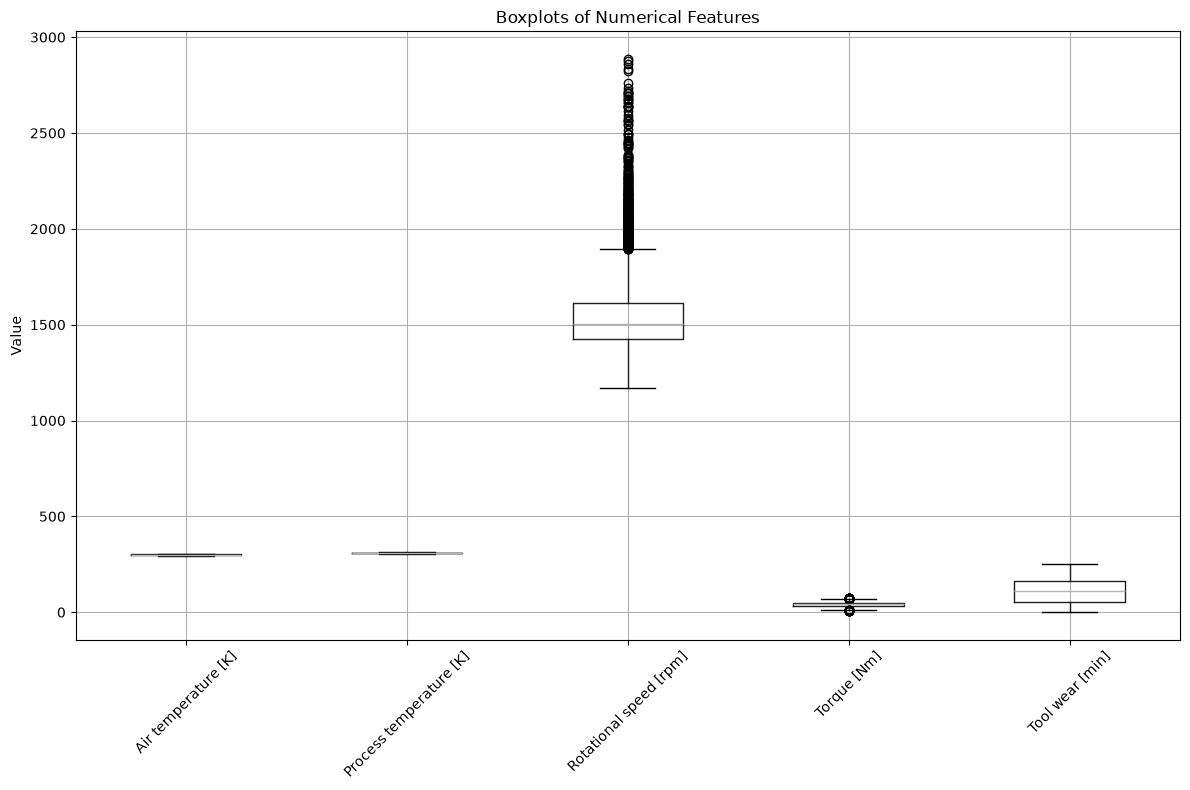

In [20]:
plt.figure(figsize=(12, 8))

df[numerical_columns].boxplot()

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

- The box plots show the spread and presence of outliers in the numerical features.
- Rotational speed and Torque contain some outlier values.
- Air temperature, Process temperature, and Tool wear show fewer or no prominent outliers.

In [21]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(column)
    print("Number of outliers:", len(outliers))
    print()

Air temperature [K]
Number of outliers: 0

Process temperature [K]
Number of outliers: 0

Rotational speed [rpm]
Number of outliers: 418

Torque [Nm]
Number of outliers: 69

Tool wear [min]
Number of outliers: 0



In [22]:
for column in ["Rotational speed [rpm]", "Torque [Nm]"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(column)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print()

Rotational speed [rpm]
Lower bound: 1139.5
Upper bound: 1895.5
Minimum: 1168
Maximum: 2886

Torque [Nm]
Lower bound: 12.800000000000011
Upper bound: 67.19999999999999
Minimum: 3.8
Maximum: 76.6



In [23]:
for column in ["Rotational speed [rpm]", "Torque [Nm]"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

Outlier treatment completed.


In [24]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

print("New feature created successfully.")
print(df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Temperature difference [K]"
]].head())

New feature created successfully.
   Air temperature [K]  Process temperature [K]  Temperature difference [K]
0                298.1                    308.6                        10.5
1                298.2                    308.7                        10.5
2                298.1                    308.5                        10.4
3                298.2                    308.6                        10.4
4                298.2                    308.7                        10.5


### Observation

- The new feature `Temperature difference [K]` (Process temperature - Air temperature) was engineered because tool/machine failures in this dataset (e.g. heat dissipation failure, HDF) are physically driven by the *gap* between process and air temperature, not by either temperature alone.
- A small temperature difference combined with low rotational speed is a known real-world driver of heat dissipation failure, so this derived feature is expected to carry more predictive signal than the two raw temperature columns individually.

In [25]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference [K]"
]

X = df[features]
y = df["Machine failure"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]']

Target:
Machine failure

Shape of X: (10000, 7)
Shape of y: (10000,)


In [26]:
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

print("Features after encoding:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)

Features after encoding:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Type_L', 'Type_M']

Shape of X: (10000, 8)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 8)
Testing set: (2000, 8)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [29]:
### SUPPORT VECTOR MACHINE (SVM)

In [30]:
svm_model = SVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [31]:
y_pred = svm_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [32]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Weighted F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.912
Weighted F1 Score: 0.934103063063063

Confusion Matrix:
[[1762  170]
 [   6   62]]


In [33]:
precision = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("Precision:", precision["weighted avg"]["precision"])
print("Recall:", precision["weighted avg"]["recall"])

y_score = svm_model.decision_function(X_test_scaled)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_score)

print("ROC-AUC:", roc_auc)

Precision: 0.9718079263535654
Recall: 0.912
ROC-AUC: 0.9661277554500061


In [34]:
# Hyperparameter Tuning using Grid Search
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"]
}

grid_search = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 100, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9646420081735009


In [35]:
# Evaluation of Tuned SVM

best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average="weighted")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Tuned SVM Accuracy:", accuracy_tuned)
print("Tuned SVM Weighted F1 Score:", f1_tuned)

print("\nTuned SVM Confusion Matrix:")
print(cm_tuned)
precision_tuned = classification_report(
    y_test,
    y_pred_tuned,
    output_dict=True
)

print("Tuned SVM Precision:", precision_tuned["weighted avg"]["precision"])
print("Tuned SVM Recall:", precision_tuned["weighted avg"]["recall"])


Tuned SVM Accuracy: 0.952
Tuned SVM Weighted F1 Score: 0.9592757894736841

Tuned SVM Confusion Matrix:
[[1852   80]
 [  16   52]]
Tuned SVM Precision: 0.9711198494581793
Tuned SVM Recall: 0.952


In [36]:
# ROC-AUC of Tuned SVM

y_score_tuned = best_svm.decision_function(X_test_scaled)

roc_auc_tuned = roc_auc_score(y_test, y_score_tuned)

print("Tuned SVM ROC-AUC:", roc_auc_tuned)

Tuned SVM ROC-AUC: 0.9471669102423578


### LOGISTIC REGRESSION

In [37]:
# Train Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [38]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [39]:
# Logistic Regression Evaluation

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic, average="weighted")
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print("Logistic Regression Weighted F1 Score:", f1_logistic)

print("\nLogistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Accuracy: 0.75
Logistic Regression Weighted F1 Score: 0.8296665133881417

Logistic Regression Confusion Matrix:
[[1443  489]
 [  11   57]]


In [40]:
# Logistic Regression Additional Metrics

precision_logistic = classification_report(
    y_test,
    y_pred_logistic,
    output_dict=True
)

print("Precision:", precision_logistic["weighted avg"]["precision"])
print("Recall:", precision_logistic["weighted avg"]["recall"])

y_score_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_logistic = roc_auc_score(y_test, y_score_logistic)

print("ROC-AUC:", roc_auc_logistic)

Precision: 0.9622413350061217
Recall: 0.75
ROC-AUC: 0.8438984289367921


### K-NEAREST NEIGHBORS (KNN)

In [41]:
# Train KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [42]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [43]:
# KNN Evaluation

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("KNN Weighted F1 Score:", f1_knn)

print("\nKNN Confusion Matrix:")
print(cm_knn)

KNN Accuracy: 0.974
KNN Weighted F1 Score: 0.9679289751234925

KNN Confusion Matrix:
[[1928    4]
 [  48   20]]


In [44]:
# KNN Additional Metrics

precision_knn = classification_report(
    y_test,
    y_pred_knn,
    output_dict=True
)

print("Precision:", precision_knn["weighted avg"]["precision"])
print("Recall:", precision_knn["weighted avg"]["recall"])

y_score_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_score_knn)

print("ROC-AUC:", roc_auc_knn)

Precision: 0.9708677462887989
Recall: 0.974
ROC-AUC: 0.8509316770186336


In [45]:
# KNN Hyperparameter Tuning

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_knn.best_params_)
print("Best Cross-Validation Score:", grid_search_knn.best_score_)

Best Parameters: {'n_neighbors': 5, 'weights': 'distance'}
Best Cross-Validation Score: 0.9672025706215381


In [46]:
# Tuned KNN Evaluation

best_knn = grid_search_knn.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test_scaled)

accuracy_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
f1_knn_tuned = f1_score(y_test, y_pred_knn_tuned, average="weighted")
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

print("Tuned KNN Accuracy:", accuracy_knn_tuned)
print("Tuned KNN Weighted F1 Score:", f1_knn_tuned)

print("\nTuned KNN Confusion Matrix:")
print(cm_knn_tuned)

Tuned KNN Accuracy: 0.9745
Tuned KNN Weighted F1 Score: 0.9691312352584406

Tuned KNN Confusion Matrix:
[[1927    5]
 [  46   22]]


In [47]:
# Tuned KNN Additional Metrics

precision_knn_tuned = classification_report(
    y_test,
    y_pred_knn_tuned,
    output_dict=True
)

print("Precision:", precision_knn_tuned["weighted avg"]["precision"])
print("Recall:", precision_knn_tuned["weighted avg"]["recall"])

y_score_knn_tuned = best_knn.predict_proba(X_test_scaled)[:, 1]

roc_auc_knn_tuned = roc_auc_score(y_test, y_score_knn_tuned)

print("ROC-AUC:", roc_auc_knn_tuned)

Precision: 0.9711816560605208
Recall: 0.9745
ROC-AUC: 0.8512133114115212


## GAUSSIAN NAIVE BAYES

In [48]:
# Train Gaussian Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [49]:
y_pred_nb = nb_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [50]:
# Gaussian Naive Bayes Evaluation

accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Gaussian Naive Bayes Accuracy:", accuracy_nb)
print("Gaussian Naive Bayes Weighted F1 Score:", f1_nb)

print("\nGaussian Naive Bayes Confusion Matrix:")
print(cm_nb)

Gaussian Naive Bayes Accuracy: 0.966
Gaussian Naive Bayes Weighted F1 Score: 0.956935861684328

Gaussian Naive Bayes Confusion Matrix:
[[1922   10]
 [  58   10]]


In [51]:
# Gaussian Naive Bayes Additional Metrics

precision_nb = classification_report(
    y_test,
    y_pred_nb,
    output_dict=True
)

print("Precision:", precision_nb["weighted avg"]["precision"])
print("Recall:", precision_nb["weighted avg"]["recall"])

y_score_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_nb = roc_auc_score(y_test, y_score_nb)

print("ROC-AUC:", roc_auc_nb)

Precision: 0.9547030303030304
Recall: 0.966
ROC-AUC: 0.8843243819266837


### DECISION TREE

In [52]:
# Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [53]:
y_pred_dt = dt_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [54]:
# Decision Tree Evaluation

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average="weighted")
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Decision Tree Weighted F1 Score:", f1_dt)

print("\nDecision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Accuracy: 0.978
Decision Tree Weighted F1 Score: 0.9775093619558736

Decision Tree Confusion Matrix:
[[1913   19]
 [  25   43]]


In [55]:
# Decision Tree Additional Metrics

precision_dt = classification_report(
    y_test,
    y_pred_dt,
    output_dict=True
)

print("Precision:", precision_dt["weighted avg"]["precision"])
print("Recall:", precision_dt["weighted avg"]["recall"])

y_score_dt = dt_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_score_dt)

print("ROC-AUC:", roc_auc_dt)

Precision: 0.9771193448516928
Recall: 0.978
ROC-AUC: 0.811259286323225


In [56]:
# Decision Tree Hyperparameter Tuning

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid_dt,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters:", grid_search_dt.best_params_)
print("Best Cross-Validation Score:", grid_search_dt.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9763283044860952


In [57]:
# Tuned Decision Tree Evaluation

best_dt = grid_search_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average="weighted")
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Accuracy:", accuracy_dt_tuned)
print("Tuned Decision Tree Weighted F1 Score:", f1_dt_tuned)

print("\nTuned Decision Tree Confusion Matrix:")
print(cm_dt_tuned)

Tuned Decision Tree Accuracy: 0.978
Tuned Decision Tree Weighted F1 Score: 0.9775093619558736

Tuned Decision Tree Confusion Matrix:
[[1913   19]
 [  25   43]]


In [58]:
# Tuned Decision Tree Additional Metrics

precision_dt_tuned = classification_report(
    y_test,
    y_pred_dt_tuned,
    output_dict=True
)

print("Precision:", precision_dt_tuned["weighted avg"]["precision"])
print("Recall:", precision_dt_tuned["weighted avg"]["recall"])

y_score_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

roc_auc_dt_tuned = roc_auc_score(y_test, y_score_dt_tuned)

print("ROC-AUC:", roc_auc_dt_tuned)

Precision: 0.9771193448516928
Recall: 0.978
ROC-AUC: 0.811259286323225


### Decision Tree Visualisation

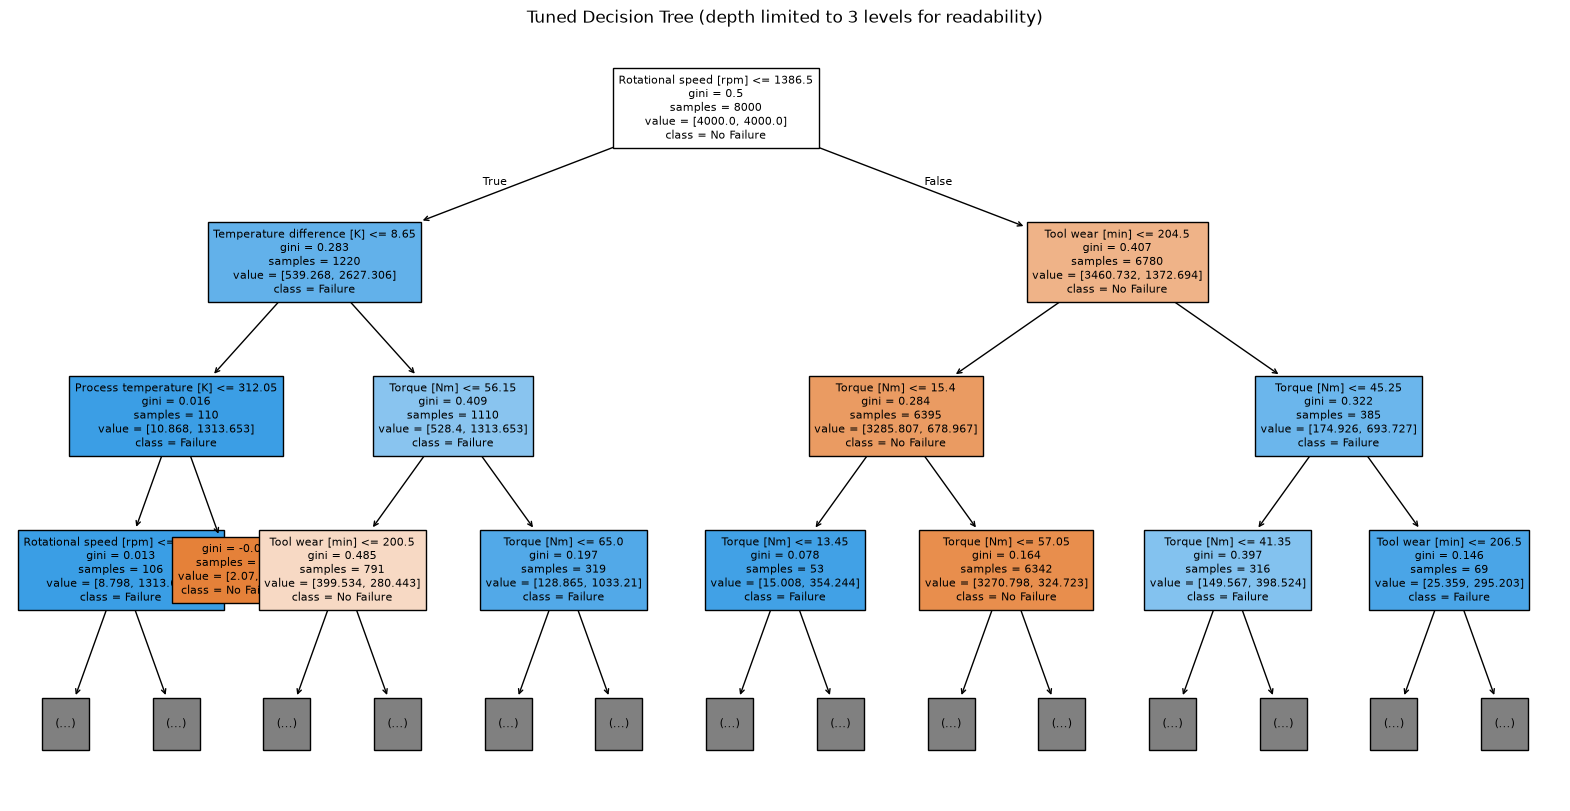

In [59]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["No Failure", "Failure"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Tuned Decision Tree (depth limited to 3 levels for readability)")
plt.show()


In [60]:
# Gaussian Naive Bayes Hyperparameter Tuning

param_grid_nb = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_search_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_nb.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-Validation Score:", grid_search_nb.best_score_)

Best Parameters: {'var_smoothing': 1e-09}
Best Cross-Validation Score: 0.9625413269165041


In [61]:
# Tuned Gaussian Naive Bayes Evaluation

best_nb = grid_search_nb.best_estimator_

y_pred_nb_tuned = best_nb.predict(X_test_scaled)

accuracy_nb_tuned = accuracy_score(y_test, y_pred_nb_tuned)
f1_nb_tuned = f1_score(y_test, y_pred_nb_tuned, average="weighted")
cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned)

print("Tuned Gaussian Naive Bayes Accuracy:", accuracy_nb_tuned)
print("Tuned Gaussian Naive Bayes Weighted F1 Score:", f1_nb_tuned)

print("\nTuned Gaussian Naive Bayes Confusion Matrix:")
print(cm_nb_tuned)
precision_nb_tuned = classification_report(
    y_test,
    y_pred_nb_tuned,
    output_dict=True
)

print("Tuned Gaussian Naive Bayes Precision:", precision_nb_tuned["weighted avg"]["precision"])
print("Tuned Gaussian Naive Bayes Recall:", precision_nb_tuned["weighted avg"]["recall"])

y_score_nb_tuned = best_nb.predict_proba(X_test_scaled)[:, 1]

roc_auc_nb_tuned = roc_auc_score(y_test, y_score_nb_tuned)

print("Tuned Gaussian Naive Bayes ROC-AUC:", roc_auc_nb_tuned)


Tuned Gaussian Naive Bayes Accuracy: 0.966
Tuned Gaussian Naive Bayes Weighted F1 Score: 0.956935861684328

Tuned Gaussian Naive Bayes Confusion Matrix:
[[1922   10]
 [  58   10]]
Tuned Gaussian Naive Bayes Precision: 0.9547030303030304
Tuned Gaussian Naive Bayes Recall: 0.966
Tuned Gaussian Naive Bayes ROC-AUC: 0.8843243819266837


In [62]:
# Logistic Regression Hyperparameter Tuning

param_grid_logistic = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search_logistic = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid_logistic,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_logistic.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_logistic.best_params_)
print("Best Cross-Validation Score:", grid_search_logistic.best_score_)

Best Parameters: {'C': 0.01}
Best Cross-Validation Score: 0.8344729586609642


In [63]:
# Tuned Logistic Regression Evaluation

best_logistic = grid_search_logistic.best_estimator_

y_pred_logistic_tuned = best_logistic.predict(X_test_scaled)

accuracy_logistic_tuned = accuracy_score(y_test, y_pred_logistic_tuned)
f1_logistic_tuned = f1_score(
    y_test,
    y_pred_logistic_tuned,
    average="weighted"
)
cm_logistic_tuned = confusion_matrix(
    y_test,
    y_pred_logistic_tuned
)

print("Tuned Logistic Regression Accuracy:", accuracy_logistic_tuned)
print("Tuned Logistic Regression Weighted F1 Score:", f1_logistic_tuned)

print("\nTuned Logistic Regression Confusion Matrix:")
print(cm_logistic_tuned)

Tuned Logistic Regression Accuracy: 0.7505
Tuned Logistic Regression Weighted F1 Score: 0.8300100539203323

Tuned Logistic Regression Confusion Matrix:
[[1443  489]
 [  10   58]]


In [64]:
# Tuned Logistic Regression Additional Metrics

precision_logistic_tuned = classification_report(
    y_test,
    y_pred_logistic_tuned,
    output_dict=True
)

print("Precision:", precision_logistic_tuned["weighted avg"]["precision"])
print("Recall:", precision_logistic_tuned["weighted avg"]["recall"])

y_score_logistic_tuned = best_logistic.predict_proba(X_test_scaled)[:, 1]

roc_auc_logistic_tuned = roc_auc_score(
    y_test,
    y_score_logistic_tuned
)

print("ROC-AUC:", roc_auc_logistic_tuned)

Precision: 0.9629568049965337
Recall: 0.7505
ROC-AUC: 0.8469050663743759


### MODEL COMPARISION

In [65]:
# Comparison of Classification Models

comparison = pd.DataFrame({
    "Model": [
        "SVM",
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_tuned,
        accuracy_logistic_tuned,
        accuracy_knn_tuned,
        accuracy_nb_tuned,
        accuracy_dt_tuned
    ],
    "Weighted F1": [
        f1_tuned,
        f1_logistic_tuned,
        f1_knn_tuned,
        f1_nb_tuned,
        f1_dt_tuned
    ],
    "Precision": [
        precision_tuned["weighted avg"]["precision"],
        precision_logistic_tuned["weighted avg"]["precision"],
        precision_knn_tuned["weighted avg"]["precision"],
        precision_nb_tuned["weighted avg"]["precision"],
        precision_dt_tuned["weighted avg"]["precision"]
    ],
    "Recall": [
        precision_tuned["weighted avg"]["recall"],
        precision_logistic_tuned["weighted avg"]["recall"],
        precision_knn_tuned["weighted avg"]["recall"],
        precision_nb_tuned["weighted avg"]["recall"],
        precision_dt_tuned["weighted avg"]["recall"]
    ],
    "ROC-AUC": [
        roc_auc_tuned,
        roc_auc_logistic_tuned,
        roc_auc_knn_tuned,
        roc_auc_nb_tuned,
        roc_auc_dt_tuned
    ]
})

comparison


,Model,Accuracy,Weighted F1,Precision,Recall,ROC-AUC
0,SVM,0.9520,0.959276,0.971120,0.9520,0.947167
1,Logistic Regression,0.7505,0.830010,0.962957,0.7505,0.846905
2,KNN,0.9745,0.969131,0.971182,0.9745,0.851213
3,Gaussian Naive Bayes,0.9660,0.956936,0.954703,0.9660,0.884324
4,Decision Tree,0.9780,0.977509,0.977119,0.9780,0.811259


### CONFUSION MATRIX VISUALIZATION

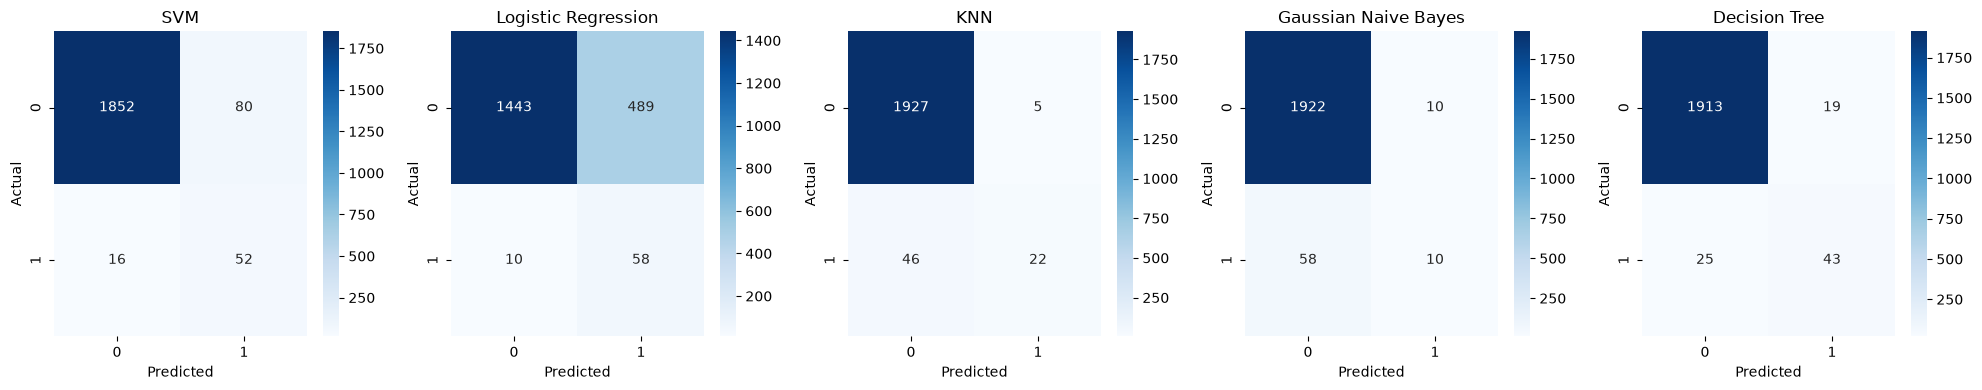

In [66]:
# Confusion Matrices of Tuned Models

confusion_matrices = [
    ("SVM", cm_tuned),
    ("Logistic Regression", cm_logistic_tuned),
    ("KNN", cm_knn_tuned),
    ("Gaussian Naive Bayes", cm_nb_tuned),
    ("Decision Tree", cm_dt_tuned)
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, cm) in zip(axes, confusion_matrices):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Observation

- SVM correctly classified 1852 non-failure and 52 failure cases.
- Logistic Regression correctly classified 1443 non-failure and 58 failure cases.
- KNN correctly classified 1927 non-failure and 22 failure cases.
- Gaussian Naive Bayes correctly classified 1922 non-failure and 10 failure cases.
- Decision Tree correctly classified 1913 non-failure and 43 failure cases.